In [100]:
from openai import OpenAI
from pydantic import BaseModel

In [101]:
from dotenv import load_dotenv

In [259]:
import os
import re
import json
from devtools import pprint, PrettyFormat
from pathlib import Path
import base64
import mimetypes
from glob import glob
import requests

In [103]:
import docker

In [297]:
from moviepy import VideoFileClip, AudioFileClip, concatenate_videoclips

In [250]:
from IPython.display import Image
from IPython.display import Audio

In [105]:
pp = PrettyFormat()

In [230]:
load_dotenv()

True

In [107]:
llm_client = OpenAI()

In [108]:
docker_client = docker.from_env()

### Utility functions

In [116]:
def image_to_data_url(path: str | Path) -> str:
    path = Path(path).expanduser().resolve()

    mime_type, _ = mimetypes.guess_type(path)
    if mime_type is None:
        mime_type = "application/octet-stream"

    image_bytes = path.read_bytes()

    b64_encoded = base64.b64encode(image_bytes).decode("ascii")

    return f"data:{mime_type};base64,{b64_encoded}"

In [123]:
image_dataset = glob('dataset/images/**/*.png')

## 01. Context gathering

In [125]:
problem_image = sorted(image_dataset)[21]

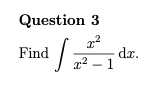

In [126]:
Image(problem_image)

## 02. Problem extraction

In [127]:
class Equations(BaseModel):
    latext: str
    unicode: str

class Prerequisites(BaseModel):
    topic: str
    reason: str

class Givens(BaseModel):
    known_facts: str
    explanation: str

class ProblemAnalysis(BaseModel):
    equations: list[Equations]
    problem_description: str
    prerequisites: list[Prerequisites]
    givens: list[Givens]

In [128]:
response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "Extract the equations, description of the maths problem, prerequisite required knowledge and known 'givens' in the problem which are helpful in answering the question."},
            {
                "type": "input_image",
                "image_url": image_to_data_url(problem_image)
            },
        ],
    }],
    text_format=ProblemAnalysis
)

In [129]:
problem_analysis = response.output_parsed

In [150]:
pprint(problem_analysis.equations[0])

Equations(
    latext='\\int \\frac{x^{2}}{x^{2}-1}\\,dx',
    unicode='∫ x² / (x² − 1) dx',
)


In [131]:
pprint(problem_analysis)

ProblemAnalysis(
    equations=[
        Equations(
            latext='\\int \\frac{x^{2}}{x^{2}-1}\\,dx',
            unicode='∫ x² / (x² − 1) dx',
        ),
        Equations(
            latext='\\int \\Bigl(1 + \\frac{1}{x^{2}-1}\\Bigr)\\,dx',
            unicode='∫ [ 1 + 1/(x² − 1) ] dx',
        ),
    ],
    problem_description='Evaluate the indefinite integral of the rational function x²/(x²−1) with respect to x.',
    prerequisites=[
        Prerequisites(
            topic='Integration of rational functions',
            reason='The integrand is a ratio of polynomials.',
        ),
        Prerequisites(
            topic='Algebraic manipulation / polynomial division',
            reason='Writing x²/(x²−1) as 1 + 1/(x²−1) simplifies the integral.',
        ),
        Prerequisites(
            topic='Partial fraction decomposition',
            reason='The term 1/(x²−1) can be split into simpler fractions 1/2[1/(x−1) − 1/(x+1)].',
        ),
        Prerequisites(
         

## 03. Solution solving steps

In [132]:
class ProblemSolvingStep(BaseModel):
    title: str
    description: str
    hints: str

class Solution(BaseModel):
    steps: list[ProblemSolvingStep]
    final_solution: str

In [133]:
solution_step_prompt = f"""Solve this problem step-by-step:

{p.problem_description}

Relevant LaTeX equation:

""" + '\n'.join([e.latext for e in p.equations])

In [134]:
print(solution_step_prompt)

Solve this problem step-by-step:

Evaluate the indefinite integral of the rational function x²⁄(x² − 1) with respect to x.

Relevant LaTeX equation:

\displaystyle \int \frac{x^{2}}{x^{2}-1}\,dx


In [135]:
problem_response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": solution_step_prompt},
        ],
    }],
    text_format=Solution
)

In [136]:
pprint(problem_response.output_parsed.steps)

[
    ProblemSolvingStep(
        title='Recognize the type of integrand',
        description=(
            'The integrand x²/(x²−1) is a rational function.  For rational functions the usual first move is to do pol'
            'ynomial (long) division so that the degree of the numerator is strictly less than the degree of the denom'
            'inator.'
        ),
        hints='Write x² as (x²−1)+1 so you can split the fraction.',
    ),
    ProblemSolvingStep(
        title='Carry out the algebraic division',
        description=(
            'Rewrite the fraction:\n'
            '\n'
            'x²/(x²−1)= (x²−1+1)/(x²−1)=1+1/(x²−1).'
        ),
        hints='You only need a single step of long division because the polynomials are of the same degree.',
    ),
    ProblemSolvingStep(
        title='Split the integral',
        description='∫ x²/(x²−1) dx = ∫1 dx + ∫ 1/(x²−1) dx.',
        hints='The first integral is immediate; focus on the second one.',
    ),
    ProblemSolvin

## 04. Gotchas

In [137]:
# TODO

Intention for this workflow is to analyse each ProblemSolvingStep and determine if there are any common mistakes learners may make when approaching this problem.

## 05. Verify solution correctness

In [138]:
# TODO using Sympy

#### Example of generated sympy script for validating solution correctness

This is using one of the fixture examples of an Integration problem

In [139]:
from sympy import (
    Symbol,
    integrate,
    diff,
    simplify,
    lambdify,
    log,
    pretty,
)

In [140]:
x = Symbol("x", real=True)
integrand = x**2 / (x**2 - 1)

antiderivative = integrate(integrand, x)

# SymPy’s default form is  x + log(x - 1)/2 - log(x + 1)/2 .
# A prettier compact version uses log((x - 1)/(x + 1)):
antiderivative = simplify(antiderivative)  # triggers the log-difference identity

print("Computed antiderivative F(x):\n")
print(pretty(antiderivative))

Computed antiderivative F(x):

    log(x - 1)   log(x + 1)
x + ────────── - ──────────
        2            2     


In [141]:
# ----------------------------------------------------------------------
# Symbolic verification  F'(x) == integrand
# ----------------------------------------------------------------------
sym_diff = diff(antiderivative, x)
sym_check = simplify(sym_diff - integrand)

In [142]:
print(pretty(sym_diff))

        1           1    
1 - ───────── + ─────────
    2⋅(x + 1)   2⋅(x - 1)


In [143]:
print("Difference after simplification: " + str(sym_check))

Difference after simplification: 0


## 06. Manim generation

In [152]:
manim_prompt = """
You are an expert Manim-CE animator and math instructor.

**Task**  
Write a single Python script called **`solve_problem.py`** (Manim CE ≥ 0.18).  
The script must define **one Scene class per solution step** so that each scene can be rendered separately:

| Scene class | Corresponds to | Render command example |
|-------------|----------------|------------------------|
""" + "\n".join(
        [
            f"| `Step{idx+1}(Scene) | '{step.title}' | `manim -pqh solve_problem.py Step{idx+1} -o step_{idx+1}` |" 
            for idx, step in enumerate(problem_response.output_parsed.steps)
        ]
    ) + """

**For *each* scene**  
1. Use a dark background (`BACKGROUND_COLOR = "#1e1e1e"`).  
2. Display the step title in a banner at the top (semi-transparent `BLUE_E`).  
3. Show and animate the LaTeX equations with `MathTex`; highlight changes (`YELLOW`, `ORANGE`).  
4. Keep ~0.5 s waits between minor animations, ~1 s between major ones.  
5. Finish the scene with a short pause (0.5 s) so the last frame isn’t cut off.

**Global visual style**  
- Text `WHITE`, titles 48 pt, equations 36 pt.  
- Use `FadeIn`, `Transform`, `Circumscribe`, and mild `LaggedStart`.  
- No audio handling — narration will be added later.

**Input data (do not alter)**  

```python
"""+pp(problem_analysis)+"""

"""+pp(problem_response.output_parsed)+"""
```

Output
Return only the contents of solve_problem.py—no extra comments—so each scene can be rendered like:

```bash
manim -pqh solve_problem.py Step1 -o step_1
manim -pqh solve_problem.py Step2 -o step_2
...
```

Constraints

Wrap repeated UI elements (title banner, highlight routine) in helper functions.

Ensure each scene renders at -pqh quality in ≤ 90 s on a modest laptop.
"""


In [154]:
print(manim_prompt)


You are an expert Manim-CE animator and math instructor.

**Task**  
Write a single Python script called **`solve_problem.py`** (Manim CE ≥ 0.18).  
The script must define **one Scene class per solution step** so that each scene can be rendered separately:

| Scene class | Corresponds to | Render command example |
|-------------|----------------|------------------------|
| `Step1(Scene) | 'Recognize the type of integrand' | `manim -pqh solve_problem.py Step1 -o step_1` |
| `Step2(Scene) | 'Carry out the algebraic division' | `manim -pqh solve_problem.py Step2 -o step_2` |
| `Step3(Scene) | 'Split the integral' | `manim -pqh solve_problem.py Step3 -o step_3` |
| `Step4(Scene) | 'Decompose 1/(x²−1) into partial fractions' | `manim -pqh solve_problem.py Step4 -o step_4` |
| `Step5(Scene) | 'Integrate each term' | `manim -pqh solve_problem.py Step5 -o step_5` |
| `Step6(Scene) | 'Assemble the result' | `manim -pqh solve_problem.py Step6 -o step_6` |

**For *each* scene**  
1. Use a dark b

In [157]:
manim_script = llm_client.responses.create(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": manim_prompt},
        ],
    }],
)

In [169]:
pprint(manim_script.output[1].content[0].text)

(
    '```python\n'
    'from manim import *\n'
    '\n'
    '# -------------------------  Global configuration  ------------------------- #\n'
    'BACKGROUND_COLOR = "#1e1e1e"\n'
    'TITLE_COLOR = WHITE\n'
    'EQUATION_COLOR = WHITE\n'
    'TITLE_FONT_SIZE = 48\n'
    'EQ_FONT_SIZE = 36\n'
    '\n'
    'config.background_color = BACKGROUND_COLOR\n'
    '\n'
    '\n'
    '# -------------------------  Helper UI utilities  -------------------------- #\n'
    'def add_title_banner(scene: Scene, title_text: str) -> None:\n'
    '    """Add a top banner with the step title."""\n'
    '    banner = Rectangle(\n'
    '        width=config.frame_width,\n'
    '        height=0.9,\n'
    '        fill_color=BLUE_E,\n'
    '        fill_opacity=0.4,\n'
    '        stroke_width=0,\n'
    '    ).to_edge(UP)\n'
    '    title = Text(\n'
    '        title_text,\n'
    '        color=TITLE_COLOR,\n'
    '        font_size=TITLE_FONT_SIZE,\n'
    '        weight=BOLD,\n'
    '    )\n'
    '    ti

In [171]:
# Cleaning markdown backticks (```python ... ```) from first and last lines
cleaned_manim_script = '\n'.join(manim_script.output[1].content[0].text.split('\n')[1:-1])

### Warning!

<span style="color: red">Do not run arbitrary Python scripts generated by LLMs without checking it first!</span>

Inspect its contents and run in an isolated environment, like a Docker container.

In [ ]:
# Use docker to execute Manim for each individual script

In [180]:
os.makedirs(host_dir, exist_ok=True)
with open('manim/solve_problem.py', 'w') as f:
    f.write(cleaned_manim_script)

In [176]:
host_dir = Path.cwd() / "manim"
volumes = {
    str(host_dir.resolve()): {
        "bind": "/manim",
        "mode": "rw",
    }
}

In [181]:
for idx, step in enumerate(problem_response.output_parsed.steps):
    container = docker_client.containers.run(
        image="manimcommunity/manim",
        command=f"manim -pqh solve_problem.py Step{idx+1} -o step_{idx+1}",
        working_dir="/manim",
        volumes=volumes,
        tty=True,
        stdin_open=True,
        auto_remove=True,
        detach=True
    )

    result = container.wait()
    print("Exit code:", result.get("StatusCode", "unknown"))

Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1


In [ ]:
# It errors with exit code 1 but still produces the videos successfully. To investigate.

In [185]:
video_step_files = glob("manim/media/videos/solve_problem/1080p60/*.mp4")

In [186]:
video_step_files

['manim/media/videos/solve_problem/1080p60/step_6.mp4',
 'manim/media/videos/solve_problem/1080p60/step_4.mp4',
 'manim/media/videos/solve_problem/1080p60/step_5.mp4',
 'manim/media/videos/solve_problem/1080p60/step_1.mp4',
 'manim/media/videos/solve_problem/1080p60/step_2.mp4',
 'manim/media/videos/solve_problem/1080p60/step_3.mp4']

In [195]:
def extract_last_frame(video, out_png=None):
    video = pathlib.Path(video)
    if out_png is None:
        out_png = video.with_suffix(".last.png")

    probe_cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "v:0",
        "-count_frames",
        "-show_entries", "stream=nb_read_frames",
        "-print_format", "json",
        str(video)
    ]
    nb_frames = int(json.loads(subprocess.check_output(probe_cmd))
                    ["streams"][0]["nb_read_frames"])

    select_filter = f"select=eq(n\\,{nb_frames-1})"
    ff_cmd = [
        "ffmpeg", "-hide_banner", "-loglevel", "error", "-y",
        "-i", str(video),
        "-vf", select_filter,
        "-vframes", "1",
        str(out_png)
    ]
    subprocess.run(ff_cmd, check=True)
    return pathlib.Path(out_png)


videos = sorted(pathlib.Path("manim/media/videos/solve_problem/1080p60").glob("step_*.mp4"))
for v in videos:
    png = extract_last_frame(v)
    print("✓", png)

✓ manim/media/videos/solve_problem/1080p60/step_1.last.png
✓ manim/media/videos/solve_problem/1080p60/step_2.last.png
✓ manim/media/videos/solve_problem/1080p60/step_3.last.png
✓ manim/media/videos/solve_problem/1080p60/step_4.last.png
✓ manim/media/videos/solve_problem/1080p60/step_5.last.png
✓ manim/media/videos/solve_problem/1080p60/step_6.last.png


## 07. Script dialogue generation

In [ ]:
# Get the last frame of each slide to build up the script

In [210]:
dia_prompt = """
You are a dialogue-designer for the **Dia** text-to-speech model.


You are a dialogue-designer for the **Dia** text-to-speech model.

**Goal**  
For every problem-solving *step* in `Solution.steps`, write a short, engaging
conversation between two speakers:

| Tag | Persona | Role |
|-----|---------|------|
| `[S1]` | Teacher | Guides, prompts, confirms |
| `[S2]` | Student | Thinks aloud, attempts answers |

Each chat must match its **corresponding slide image** (the final
frame of that step’s video).

**Conversation rules**

1. **Length** – 4 – 6 utterances total (≈ 70 words).  
2. **Tone** – friendly, notebook-style “chalk & talk”.  
3. **Slide awareness** – Refer to what’s *visible* (symbols, highlights,
   colours) without restating the full equation.  
4. **Pedagogical arc** –  
   * Teacher poses a micro-question → Student responds → Teacher affirms
     or corrects → Teacher wraps up the step.  
5. **Dia pronunciation constraint** –  
   Dia cannot voice raw math symbols or Unicode. **Spell everything out:**

   | Symbol | Speak as… |
   |--------|-----------|
   | `x²`   | “x squared” |
   | `/`    | “divided by” |
   | `∫`    | “integral of” |
   | `→`    | “implies” |
   | `ln`   | “natural log” |

   *Never include LaTeX, Unicode superscripts, or subscripts directly in
   the dialogue.*  
6. **Optional flavour tags** – Use sparingly at natural points in the conversation.  
   `(laughs) (sighs) (gasps) …` *(full list provided below)*  
7. **No extra stage directions** beyond the allowed tag.

**Allowed tags**  

```
(laughs) (clears throat) (sighs) (gasps) (coughs) (singing) (sings) (mumbles) (beep) (groans) (sniffs) (claps) (screams) (inhales) (exhales) (applause) (burps) (humming) (sneezes) (chuckle) (whistles)
```


Do not merge steps; keep chats in original order.

─────────────────── EXAMPLE (abridged) ───────────────────

Step 2 – Partial Fractions
[S1] See the two factors in the denominator?
[S2] Yep—(x − 1) and (x + 1). Should we split the fraction next?
[S1] Exactly. What constants go on top?
[S2] I’m guessing A over (x − 1) and B over (x + 1).
[S1] Good guess—and with x = 1 you’ll find A = ½. Keep going! (chuckle) 
────────────────────────────────────────────────────────────────────────


Input data:

```python
"""+pp(problem_analysis)+"""

"""+pp(problem_response.output_parsed)+"""
```
"""

In [211]:
base64_slide_images = [{"type": "input_image", "image_url": image_to_data_url(i)} for i in glob("manim/media/videos/solve_problem/1080p60/*.last.png")]

In [215]:
script_collected_prompt = [{ "type": "input_text", "text": dia_prompt }] + base64_slide_images

In [212]:
class StepConversation(BaseModel):
    step: str
    script: str

class ConversationScript(BaseModel):
    step: list[StepConversation]

In [217]:
script_response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": script_collected_prompt,
    }],
    text_format=ConversationScript
)

In [218]:
pprint(script_response.output_parsed)

ConversationScript(
    slides=[
        SlideScript(
            step='Recognize the type of integrand',
            conversation=(
                '[S1] The screen shows our integrand. What kind of creature is x squared over x squared minus one?\n'
                '[S2] A rational function—two polynomials in a fraction.\n'
                '[S1] Exactly. And the orange note below nudges us toward which first move?\n'
                '[S2] Polynomial division, because the top and bottom have the same degree.\n'
                '[S1] Perfect. We’ll rewrite the numerator as denominator plus a remainder next.\n'
                '[S2] Long-division goggles on! (chuckle)'
            ),
        ),
        SlideScript(
            step='Carry out the algebraic division',
            conversation=(
                '[S1] Notice the white denominator reappearing inside the numerator?\n'
                '[S2] Yep—x squared became parentheses x squared minus one close parentheses plus one.\n'
   

In [221]:
conversation_script = script_response.output_parsed

In [224]:
conversation_script.slides[0].conversation

'[S1] The screen shows our integrand. What kind of creature is x squared over x squared minus one?\n[S2] A rational function—two polynomials in a fraction.\n[S1] Exactly. And the orange note below nudges us toward which first move?\n[S2] Polynomial division, because the top and bottom have the same degree.\n[S1] Perfect. We’ll rewrite the numerator as denominator plus a remainder next.\n[S2] Long-division goggles on! (chuckle)'

# 08. Text to Speech

In [240]:
def query_dia(payload):
    response = requests.post("https://router.huggingface.co/fal-ai/fal-ai/dia-tts", headers={
        "Authorization": f"Bearer {os.environ['HF_TOKEN']}",
    }, json=payload)
    return response.json()

In [248]:
os.makedirs("audio", exist_ok=True)

In [249]:
for idx, slide in enumerate(conversation_script.slides):
    print("Generating conversation")
    audio_result = query_dia({
       "text": slide.conversation
    })
    print("Preparing to download")
    local_filename = f"audio/step_{idx+1}.wav"
    with requests.get(audio_result['audio']['url'], stream=True, timeout=15) as r:
        r.raise_for_status()
        with open(local_filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=64 * 1024):
                if chunk:
                    f.write(chunk)
    print(f"Local file {local_filename} saved")

Generating conversation
Preparing to download
Local file audio/step_1.wav saved
Generating conversation
Preparing to download
Local file audio/step_2.wav saved
Generating conversation
Preparing to download
Local file audio/step_3.wav saved
Generating conversation
Preparing to download
Local file audio/step_4.wav saved
Generating conversation
Preparing to download
Local file audio/step_5.wav saved
Generating conversation
Preparing to download
Local file audio/step_6.wav saved


In [ ]:
## Debugging can use Audio from IPython
# Audio(audio)

# 09. ffmpeg stitching video and audio together

In [282]:
step_videos_glob   = "manim/media/videos/solve_problem/1080p60/step_*.mp4"
step_audio_glob    = "audio/step_*.wav"
output_dir         = Path("output")
output_dir.mkdir(exist_ok=True)

In [283]:
step_pattern = re.compile(r"step_(\d+)\.")

In [284]:
def get_step_idx(path: str) -> int:
    """Extract the numeric index from 'step_<n>.<ext>'."""
    m = step_pattern.search(Path(path).name)
    return int(m.group(1)) if m else -1

In [285]:
videos = {get_step_idx(p): p for p in glob(step_videos_glob)}
audios = {get_step_idx(p): p for p in glob(step_audio_glob)}

In [289]:
common_steps = sorted(set(videos.keys()) & set(audios.keys()))
if not common_steps:
    raise RuntimeError("No matching step_N.mp4 / step_N.wav pairs found.")

In [299]:
for n in common_steps:
    vid_path = videos[n]
    wav_path = audios[n]
    out_path = output_dir / f"step_{n:02d}.mp4"

    print(f"[step {n}] video → {vid_path}")
    print(f"[step {n}] audio → {wav_path}")

    
    with VideoFileClip(vid_path) as vclip, AudioFileClip(wav_path) as aclip:
    
        # ── 1. Extend the video if the audio is longer ────────────────────
        if aclip.duration > vclip.duration + 0.02:      # 20-ms slack
            freeze_dur = aclip.duration - vclip.duration
    
            # create a still ImageClip from the very last frame
            last_frame = (
                vclip
                .to_ImageClip(vclip.duration)           # snapshot at end
                .with_duration(freeze_dur)
            )
    
            # stitch original + frozen tail
            vclip = concatenate_videoclips([vclip, last_frame])
    
        # ── 2. Add the new soundtrack ──────────────────────────────────────
        vclip = vclip.with_audio(aclip).with_duration(aclip.duration)
    
        # ── 3. Write the result ────────────────────────────────────────────
        vclip.write_videofile(
            str(out_path),
            codec="libx264",
            audio_codec="aac",
            fps=vclip.fps,
            temp_audiofile=str(output_dir / "temp-audio.m4a"),
            remove_temp=True,
            threads=4,
            logger=None,
        )

print(f"\nDone!  Composited clips saved to → {output_dir.resolve()}")

[step 1] video → manim/media/videos/solve_problem/1080p60/step_1.mp4
[step 1] audio → audio/step_1.wav
{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 461, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 3.9, 'bitrate': 468, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 461, 'video_fps': 60.0, 'video_duration': 3.9, 'video_n_frames': 234}
/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13

/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/moviepy/video/io/ffmpeg_reader.py:178: UserWarning: In file manim/media/videos/solve_problem/1080p60/step_2.mp4, 6220800 bytes wanted but 0 bytes read at frame index 324 (out of a total 324 frames), at time 5.40/5.40 sec. Using the last valid frame instead.
  warnings.warn(


{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 351, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 5.4, 'bitrate': 358, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 351, 'video_fps': 60.0, 'video_duration': 5.4, 'video_n_frames': 324}
/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -i manim/media/videos/solve_problem/10

/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/moviepy/video/io/ffmpeg_reader.py:178: UserWarning: In file manim/media/videos/solve_problem/1080p60/step_3.mp4, 6220800 bytes wanted but 0 bytes read at frame index 234 (out of a total 234 frames), at time 3.90/3.90 sec. Using the last valid frame instead.
  warnings.warn(


{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 330, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 3.9, 'bitrate': 338, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 330, 'video_fps': 60.0, 'video_duration': 3.9, 'video_n_frames': 234}
/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -i manim/media/videos/solve_problem/10

...

{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 489, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 6.3, 'bitrate': 496, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 489, 'video_fps': 60.0, 'video_duration': 6.3, 'video_n_frames': 378}
/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -i manim/media/videos/solve_problem/10

/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/moviepy/video/io/ffmpeg_reader.py:178: UserWarning: In file manim/media/videos/solve_problem/1080p60/step_5.mp4, 6220800 bytes wanted but 0 bytes read at frame index 438 (out of a total 438 frames), at time 7.30/7.30 sec. Using the last valid frame instead.
  warnings.warn(


{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 341, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 7.3, 'bitrate': 348, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 341, 'video_fps': 60.0, 'video_duration': 7.3, 'video_n_frames': 438}
/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -i manim/media/videos/solve_problem/10

/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/moviepy/video/io/ffmpeg_reader.py:178: UserWarning: In file manim/media/videos/solve_problem/1080p60/step_6.mp4, 6220800 bytes wanted but 0 bytes read at frame index 336 (out of a total 336 frames), at time 5.60/5.60 sec. Using the last valid frame instead.
  warnings.warn(


{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 391, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 5.6, 'bitrate': 398, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 391, 'video_fps': 60.0, 'video_duration': 5.6, 'video_n_frames': 336}
/Users/caleb/Projects/mokotahi/maths/.venv/lib/python3.13/site-packages/imageio_ffmpeg/binaries/ffmpeg-macos-aarch64-v7.1 -i manim/media/videos/solve_problem/10

In [317]:
OUT_DIR = Path("output")
OUT_VIDEO = Path("final") / f"{Path(problem_image).stem}.mp4"
os.makedirs("final", exist_ok=True)

In [312]:
step_re = re.compile(r"step_(\d+)\.mp4$")
step_clips = sorted(
    OUT_DIR.glob("step_*.mp4"),
    key=lambda p: int(step_re.search(p.name).group(1))
)

In [313]:
if not step_clips:
    raise RuntimeError("No step_*.mp4 files found in the output folder!")

In [314]:
print("Concatenating:")
for p in step_clips:
    print("   •", p.name)
    
concat_file = OUT_DIR / "concat_list.txt"
with concat_file.open("w", encoding="utf-8") as f:
    for clip in step_clips:
        f.write(f"file '{clip.resolve()}'\n")


Concatenating:
   • step_01.mp4
   • step_02.mp4
   • step_03.mp4
   • step_04.mp4
   • step_05.mp4
   • step_06.mp4


In [318]:
cmd = [
    "ffmpeg",
    "-f", "concat",
    "-safe", "0",
    "-i", str(concat_file),
    "-c", "copy",
    str(OUT_VIDEO)
]

In [319]:
print("\nRunning:", " ".join(cmd))
subprocess.run(cmd, check=True)
print("\n🎉  Done!  Final video saved to →", OUT_VIDEO.resolve())


Running: ffmpeg -f concat -safe 0 -i output/concat_list.txt -c copy final/ch4q3.mp4

🎉  Done!  Final video saved to → /Users/caleb/Projects/Mokotahi/maths/notebooks/final/ch4q3.mp4


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex